# 10 — Camera Dataset Preparation

Prepare `dataset/Camera captured eye Dataset` as a **separate** camera-eye classification dataset.

This notebook is **data preparation only**. It does **not**:
- modify `efficientnetv2_b0_4class_best.keras` or any other model file
- retrain the existing 4-class fundus EfficientNetV2-B0
- modify the existing 5885-image fundus dataset
- modify existing training/validation/test CSV files
- modify Grad-CAM, FastAPI backend, or React frontend
- change the verified **84.94%** fundus test accuracy
- mix camera images into the 5885-image fundus dataset
- train YOLO or EfficientNet

**Camera class mapping (this dataset only):** `0 = Cataract` · `1 = Normal`

This mapping is **not** the fundus 4-class mapping (`0=Normal`, `1=Cataract`, `2=DR`, `3=Glaucoma`). Diabetic Retinopathy and Glaucoma are **not present** here and are not introduced.


In [1]:
# STEP 0 — Imports, paths, configuration, protected-file fingerprints
from __future__ import annotations

import hashlib
import json
import math
import shutil
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageDraw, UnidentifiedImageError

PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:/Practice Projects/Disease Detection"),
]
PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if (p / "dataset").exists() and (p / "preprocessing").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root.")

CAMERA_ROOT = PROJECT_ROOT / "dataset" / "Camera captured eye Dataset"
EXISTING_META = PROJECT_ROOT / "preprocessing" / "dataset_metadata_v2.csv"
SPLIT_DIR = PROJECT_ROOT / "preprocessing" / "splits_v2"
PREPARED_DIR = PROJECT_ROOT / "camera_dataset_prepared"
REPORT_DIR = PROJECT_ROOT / "reports" / "camera_dataset_preparation"
PREVIEW_DIR = REPORT_DIR / "previews"
REJECTED_IMG_DIR = REPORT_DIR / "rejected_crop_images"

SPLITS = ("train", "val", "test")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
EXPECTED_SPLIT_COUNTS = {"train": 1385, "val": 396, "test": 198}
EXPECTED_TOTAL_IMAGES = 1979
EXPECTED_FUNDUS_ROWS = 5885
VERIFIED_FUNDUS_ACCURACY = "84.94%"

# Verified camera mapping from notebook 09. Do not silently remap.
CAMERA_CLASS_MAP = {0: "Cataract", 1: "Normal"}
VALID_CLASS_IDS = set(CAMERA_CLASS_MAP)
FUNDUS_CLASS_MAP = {0: "Normal", 1: "Cataract", 2: "Diabetic Retinopathy", 3: "Glaucoma"}

# ROI / quality — configurable. Crops are NOT resized to 224x224 here.
PAD_RATIO = 0.10
PAD_MIN_PX = 2
MIN_CROP_SIDE_PX = 16
MIN_CROP_AREA_PX = 16 * 16
MIN_MEAN_BRIGHTNESS = 8.0
MAX_MEAN_BRIGHTNESS = 247.0
MIN_STRUCTURE_STD = 3.0
MIN_LAPLACIAN_VAR = 5.0
JPEG_QUALITY = 95

PROCESSING_CONFIG = {
    "pad_ratio": PAD_RATIO,
    "pad_min_px": PAD_MIN_PX,
    "min_crop_side_px": MIN_CROP_SIDE_PX,
    "min_crop_area_px": MIN_CROP_AREA_PX,
    "min_mean_brightness": MIN_MEAN_BRIGHTNESS,
    "max_mean_brightness": MAX_MEAN_BRIGHTNESS,
    "min_structure_std": MIN_STRUCTURE_STD,
    "min_laplacian_var": MIN_LAPLACIAN_VAR,
    "jpeg_quality": JPEG_QUALITY,
    "resize_to_224": False,
    "keep_source_splits": True,
    "shuffle_all_images": False,
    "class_mapping": {str(k): v for k, v in CAMERA_CLASS_MAP.items()},
}

assert PREPARED_DIR.name == "camera_dataset_prepared"
assert PREPARED_DIR.resolve() != CAMERA_ROOT.resolve()

PROTECTED_RELATIVE = [
    "preprocessing/dataset_metadata_v2.csv",
    "preprocessing/splits_v2/train.csv",
    "preprocessing/splits_v2/validation.csv",
    "preprocessing/splits_v2/test.csv",
    "preprocessing/train_v2.csv",
    "preprocessing/validation_v2.csv",
    "preprocessing/test_v2.csv",
    "preprocessing/splits_v2_metadata.csv",
    "model/efficientnetv2_b0_4class_best.keras",
    "model/efficientnetv2_b0_4class_final.keras",
    "model/model_metadata_v2.json",
    "reports/model_v2/test_metrics.json",
    "reports/model_analysis_v2/overall_metrics.json",
    "reports/model_analysis_v2/final_analysis_summary.json",
    "backend/app/main.py",
    "backend/app/model_service.py",
    "backend/app/gradcam.py",
    "frontend/package.json",
]


def file_fingerprint(path: Path) -> dict:
    if not path.exists():
        return {"path": str(path), "exists": False, "size": None, "md5": None, "mtime_ns": None}
    data = path.read_bytes()
    return {
        "path": str(path),
        "exists": True,
        "size": len(data),
        "md5": hashlib.md5(data).hexdigest(),
        "mtime_ns": path.stat().st_mtime_ns,
    }


PROTECTED_BEFORE = {rel: file_fingerprint(PROJECT_ROOT / rel) for rel in PROTECTED_RELATIVE}

REPORT_DIR.mkdir(parents=True, exist_ok=True)
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("CAMERA_ROOT  :", CAMERA_ROOT)
print("CAMERA_ROOT exists:", CAMERA_ROOT.exists())
print("PREPARED_DIR :", PREPARED_DIR)
print("REPORT_DIR   :", REPORT_DIR)
print("Camera class map:", CAMERA_CLASS_MAP)
print("Fundus class map (UNCHANGED, not used for this dataset):", FUNDUS_CLASS_MAP)
print("Resize to 224x224 at this stage: NO")
print("Protected files fingerprinted:", len(PROTECTED_BEFORE))
print("Existing 5885-image dataset will NOT be written to.")
print("Existing EfficientNetV2-B0 will NOT be loaded or modified.")


PROJECT_ROOT : d:\Practice Projects\Disease Detection
CAMERA_ROOT  : d:\Practice Projects\Disease Detection\dataset\Camera captured eye Dataset
CAMERA_ROOT exists: True
PREPARED_DIR : d:\Practice Projects\Disease Detection\camera_dataset_prepared
REPORT_DIR   : d:\Practice Projects\Disease Detection\reports\camera_dataset_preparation
Camera class map: {0: 'Cataract', 1: 'Normal'}
Fundus class map (UNCHANGED, not used for this dataset): {0: 'Normal', 1: 'Cataract', 2: 'Diabetic Retinopathy', 3: 'Glaucoma'}
Resize to 224x224 at this stage: NO
Protected files fingerprinted: 18
Existing 5885-image dataset will NOT be written to.
Existing EfficientNetV2-B0 will NOT be loaded or modified.


## STEP 1 — Re-audit before processing

Load the camera dataset and verify split counts, class distribution, image/label pairing, YOLO coordinate validity, multi-box images, resolutions, formats, and corruption.

Semantic labels are **not** silently corrected.


In [2]:
# STEP 1a — Inventory images + YOLO labels (pairing, boxes, validity)
def parse_yolo_label(path: Path) -> dict:
    raw = path.read_text(encoding="utf-8", errors="replace")
    rows = []
    issues = []
    for i, line in enumerate(raw.splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) < 5:
            issues.append(f"line {i}: expected >=5 fields, got {len(parts)}")
            continue
        try:
            cid = int(float(parts[0]))
            xc, yc, bw, bh = (float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4]))
        except ValueError:
            issues.append(f"line {i}: non-numeric YOLO fields")
            continue
        yolo_ok = (
            cid >= 0
            and 0.0 <= xc <= 1.0
            and 0.0 <= yc <= 1.0
            and 0.0 < bw <= 1.0
            and 0.0 < bh <= 1.0
        )
        extra = []
        if cid not in VALID_CLASS_IDS:
            extra.append(f"line {i}: class_id {cid} is not in verified mapping {CAMERA_CLASS_MAP}")
        if not yolo_ok:
            issues.append(f"line {i}: values outside YOLO normalized range or invalid class")
        issues.extend(extra)
        rows.append(
            {
                "class_id": cid,
                "xc": xc,
                "yc": yc,
                "bw": bw,
                "bh": bh,
                "yolo_ok": yolo_ok and cid in VALID_CLASS_IDS,
                "line_no": i,
            }
        )
    return {"rows": rows, "issues": issues, "raw_empty": not bool(rows)}


records = []
unmatched_labels = []
unmatched_images = []
empty_labels = []
invalid_box_rows = []
class_id_counter = Counter()
box_counter = Counter()
multi_box_records = []

for split in SPLITS:
    img_dir = CAMERA_ROOT / split / "images"
    lab_dir = CAMERA_ROOT / split / "labels"
    if not img_dir.is_dir() or not lab_dir.is_dir():
        raise FileNotFoundError(f"Missing YOLO layout for split={split}: {img_dir} / {lab_dir}")
    images = {p.stem: p for p in img_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS}
    labels = {p.stem: p for p in lab_dir.iterdir() if p.is_file() and p.suffix.lower() == ".txt"}
    for stem, img_path in sorted(images.items()):
        lab_path = labels.pop(stem, None)
        rec = {
            "split": split,
            "stem": stem,
            "image_path": str(img_path),
            "filename": img_path.name,
            "label_path": str(lab_path) if lab_path else None,
            "has_label": lab_path is not None,
        }
        if lab_path is None:
            rec.update(
                {
                    "n_boxes": 0,
                    "class_ids": [],
                    "yolo_valid": False,
                    "label_issues": ["missing label file"],
                    "boxes": [],
                }
            )
            unmatched_images.append(rec)
        else:
            parsed = parse_yolo_label(lab_path)
            ids = [r["class_id"] for r in parsed["rows"]]
            rec.update(
                {
                    "n_boxes": len(parsed["rows"]),
                    "class_ids": ids,
                    "primary_class": ids[0] if ids else None,
                    "unique_classes": sorted(set(ids)),
                    "yolo_valid": bool(parsed["rows"])
                    and all(r["yolo_ok"] for r in parsed["rows"])
                    and not parsed["issues"],
                    "label_issues": parsed["issues"],
                    "boxes": parsed["rows"],
                }
            )
            if parsed["raw_empty"]:
                empty_labels.append(rec)
            for box in parsed["rows"]:
                class_id_counter[box["class_id"]] += 1
                if not box["yolo_ok"]:
                    invalid_box_rows.append({"split": split, "filename": img_path.name, **box})
            box_counter[len(ids)] += 1
            if len(ids) > 1:
                multi_box_records.append(rec)
        records.append(rec)
    for stem, lab_path in sorted(labels.items()):
        unmatched_labels.append({"split": split, "label": lab_path.name, "stem": stem})

split_image_counts = {s: sum(1 for r in records if r["split"] == s) for s in SPLITS}
split_label_counts = {s: sum(1 for r in records if r["split"] == s and r["has_label"]) for s in SPLITS}
n_valid_label_files = sum(1 for r in records if r.get("yolo_valid"))
n_invalid_label_files = len(records) - n_valid_label_files

print("=== Source inventory ===")
print("Images per split:")
for split in SPLITS:
    expected = EXPECTED_SPLIT_COUNTS[split]
    n_img = split_image_counts[split]
    n_lab = split_label_counts[split]
    flag = "OK" if n_img == expected and n_lab == expected else "MISMATCH vs previous audit"
    print(f"  {split:5} images={n_img:4d}  labels_matched={n_lab:4d}  expected={expected}  [{flag}]")
print("TOTAL images:", len(records), "expected", EXPECTED_TOTAL_IMAGES)
print("Images missing labels:", len(unmatched_images))
print("Labels missing images:", len(unmatched_labels))
print("Empty label files:", len(empty_labels))
print("Fully valid YOLO label files:", n_valid_label_files)
print("Label files with issues / empty / missing:", n_invalid_label_files)
print("Invalid YOLO box rows:", len(invalid_box_rows))
print("Boxes per image:", dict(sorted(box_counter.items())))
print("Class-id box counts:", dict(sorted(class_id_counter.items())))
print("Images with multiple boxes:", len(multi_box_records))
if multi_box_records:
    print("Multiple-box files (not discarded):")
    for rec in multi_box_records:
        print(f"  {rec['split']}/{rec['filename']}  n_boxes={rec['n_boxes']}  class_ids={rec['class_ids']}")
if unmatched_images:
    print("Missing labels (first 10):", [r["filename"] for r in unmatched_images[:10]])
if unmatched_labels:
    print("Unmatched labels (first 10):", [r["label"] for r in unmatched_labels[:10]])
if invalid_box_rows:
    print("Invalid boxes (first 10):")
    for row in invalid_box_rows[:10]:
        print(" ", row)


=== Source inventory ===
Images per split:
  train images=1385  labels_matched=1385  expected=1385  [OK]
  val   images= 396  labels_matched= 396  expected=396  [OK]
  test  images= 198  labels_matched= 198  expected=198  [OK]
TOTAL images: 1979 expected 1979
Images missing labels: 0
Labels missing images: 0
Empty label files: 0
Fully valid YOLO label files: 1979
Label files with issues / empty / missing: 0
Invalid YOLO box rows: 0
Boxes per image: {1: 1974, 2: 5}
Class-id box counts: {0: 1719, 1: 265}
Images with multiple boxes: 5
Multiple-box files (not discarded):
  train/image_127_png.rf.5ff6bb2081ff5b88cb4901e0d51a6efe.jpg  n_boxes=2  class_ids=[0, 0]
  train/image_226_png.rf.0fd99542b943289137d645b15d909a00.jpg  n_boxes=2  class_ids=[0, 0]
  train/image_88_png.rf.40e51b0d7f46a1b1fc3a65a7b8cb9eb3.jpg  n_boxes=2  class_ids=[1, 1]
  val/image_145_png.rf.3198e992197f49f195ac6baf0bcb163e.jpg  n_boxes=2  class_ids=[0, 0]
  val/image_52_png.rf.927ea4e4d9909cff992a284e46724c02.jpg  n_box

In [3]:
# STEP 1b — Class 0 / class 1 distribution (boxes and primary image class)
print("=== Class distribution (do not remap) ===")
print("Verified mapping: 0 = Cataract, 1 = Normal")
print("Box counts by class_id:", dict(sorted(class_id_counter.items())))

primary = []
for rec in records:
    ids = rec.get("class_ids") or []
    primary.append(ids[0] if ids else None)

print("\nImages by primary (first-box) class_id:")
print(pd.Series(primary, name="primary_class").value_counts(dropna=False).sort_index())

tmp = pd.DataFrame({"split": [r["split"] for r in records], "primary_class": primary})
print("\nImages per split x primary class:")
print(pd.crosstab(tmp["split"], tmp["primary_class"], dropna=False))

box_split_class = []
for rec in records:
    for box in rec.get("boxes") or []:
        box_split_class.append({"split": rec["split"], "class_id": box["class_id"], "disease_name": CAMERA_CLASS_MAP.get(box["class_id"], "UNKNOWN")})
box_df = pd.DataFrame(box_split_class)
print("\nBoxes per split x class_id:")
print(pd.crosstab(box_df["split"], box_df["class_id"]))
print("\nUnknown class_id boxes:", int((box_df["disease_name"] == "UNKNOWN").sum()) if len(box_df) else 0)


=== Class distribution (do not remap) ===
Verified mapping: 0 = Cataract, 1 = Normal
Box counts by class_id: {0: 1719, 1: 265}

Images by primary (first-box) class_id:
primary_class
0    1715
1     264
Name: count, dtype: int64

Images per split x primary class:
primary_class     0    1
split                   
test            169   29
train          1188  197
val             358   38

Boxes per split x class_id:
class_id     0    1
split              
test       169   29
train     1190  198
val        360   38

Unknown class_id boxes: 0


In [4]:
# STEP 1c — Image properties, formats, resolutions, corruption
readable = []
corrupt = []
format_counter = Counter()
size_counter = Counter()
aspect_buckets = Counter()


def aspect_bucket(w, h):
    ar = w / h if h else 0
    if abs(ar - 1) < 0.08:
        return "square(~1:1)"
    if ar > 1:
        return "landscape(>1)"
    return "portrait(<1)"


for rec in records:
    path = Path(rec["image_path"])
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            fmt = (im.format or path.suffix.lower().lstrip(".")).upper()
            rgb = im.convert("RGB")
            w, h = rgb.size
        rec.update(
            {
                "readable": True,
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 4) if h else None,
                "format": fmt,
            }
        )
        readable.append(rec)
        format_counter[fmt] += 1
        size_counter[(w, h)] += 1
        aspect_buckets[aspect_bucket(w, h)] += 1
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        rec.update({"readable": False, "error": str(exc), "width": None, "height": None, "format": None})
        corrupt.append(rec)

print("=== Image readability / properties ===")
print("Readable:", len(readable), "Corrupt/unreadable:", len(corrupt))
if corrupt:
    for rec in corrupt[:20]:
        print("  CORRUPT", rec["filename"], rec.get("error"))

print("Formats:", dict(format_counter))
print("Aspect buckets:", dict(aspect_buckets))
print("Unique resolutions:", len(size_counter))
print("Most common resolutions:")
for (w, h), n in size_counter.most_common(10):
    print(f"  {w}x{h}: {n}")

widths = [r["width"] for r in readable]
heights = [r["height"] for r in readable]
print(f"Width  min/median/max: {min(widths)} / {int(np.median(widths))} / {max(widths)}")
print(f"Height min/median/max: {min(heights)} / {int(np.median(heights))} / {max(heights)}")
print("Semantic labels were not edited.")


=== Image readability / properties ===
Readable: 1979 Corrupt/unreadable: 0
Formats: {'JPEG': 1979}
Aspect buckets: {'portrait(<1)': 34, 'square(~1:1)': 675, 'landscape(>1)': 1270}
Unique resolutions: 518
Most common resolutions:
  120x80: 568
  640x426: 46
  56x56: 37
  54x54: 35
  55x55: 34
  58x58: 32
  57x57: 32
  59x59: 31
  60x60: 30
  53x53: 30
Width  min/median/max: 41 / 120 / 640
Height min/median/max: 41 / 80 / 640
Semantic labels were not edited.


## STEP 2 — Class mapping

Use the mapping verified in notebook 09 (visual/evidential, no official `data.yaml` names file):

| YOLO `class_id` | `disease_name` | Folder |
| --- | --- | --- |
| `0` | Cataract | `Cataract/` |
| `1` | Normal | `Normal/` |

Do **not** introduce Diabetic Retinopathy or Glaucoma. They are not labeled in this dataset.


In [5]:
# STEP 2 — Document class mapping (no remapping, no extra classes)
print("CAMERA dataset class mapping (explicit, frozen for this notebook):")
for cid, name in CAMERA_CLASS_MAP.items():
    print(f"  {cid} = {name}")

print("\nClasses that will NOT be created:")
print("  Diabetic Retinopathy — absent from camera labels")
print("  Glaucoma — absent from camera labels")

print("\nContrast with existing fundus 4-class mapping (NOT used here, NOT modified):")
for cid, name in FUNDUS_CLASS_MAP.items():
    print(f"  fundus {cid} = {name}")

unknown_ids = sorted(set(class_id_counter) - VALID_CLASS_IDS)
print("\nUnexpected class IDs in labels:", unknown_ids if unknown_ids else "none")
print("No semantic label values were rewritten.")


CAMERA dataset class mapping (explicit, frozen for this notebook):
  0 = Cataract
  1 = Normal

Classes that will NOT be created:
  Diabetic Retinopathy — absent from camera labels
  Glaucoma — absent from camera labels

Contrast with existing fundus 4-class mapping (NOT used here, NOT modified):
  fundus 0 = Normal
  fundus 1 = Cataract
  fundus 2 = Diabetic Retinopathy
  fundus 3 = Glaucoma

Unexpected class IDs in labels: none
No semantic label values were rewritten.


## STEP 3–5 — ROI extraction, quality filtering, split-preserving export

For every image:
1. Read the YOLO label.
2. Convert normalized `x_center y_center width height` to pixel coordinates.
3. Crop the annotated region with configurable padding, clamped to the image.
4. Keep the crop's natural aspect ratio (no square-forcing, no 224×224 resize).
5. Convert to RGB and save accepted crops under the **original** `train` / `val` / `test` split.

Multiple valid boxes from one image become multiple deterministic crops (`*_box00`, `*_box01`, …) with metadata back to the source file. Boxes are not arbitrarily discarded.

Rejected crops are recorded in `rejected_crops.csv` (and copied under `reports/.../rejected_crop_images/` for audit). Nothing is deleted silently.


In [6]:
# STEP 3–5 helpers — geometry, quality, export paths
def yolo_to_xyxy(xc, yc, bw, bh, width, height):
    x1 = (xc - bw / 2.0) * width
    y1 = (yc - bh / 2.0) * height
    x2 = (xc + bw / 2.0) * width
    y2 = (yc + bh / 2.0) * height
    return x1, y1, x2, y2


def padded_clamp_box(xc, yc, bw, bh, width, height, pad_ratio, pad_min_px):
    x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, width, height)
    box_w = max(0.0, x2 - x1)
    box_h = max(0.0, y2 - y1)
    pad_x = max(float(pad_min_px), box_w * pad_ratio)
    pad_y = max(float(pad_min_px), box_h * pad_ratio)
    x1 -= pad_x
    y1 -= pad_y
    x2 += pad_x
    y2 += pad_y
    x1 = min(max(x1, 0.0), float(width))
    y1 = min(max(y1, 0.0), float(height))
    x2 = min(max(x2, 0.0), float(width))
    y2 = min(max(y2, 0.0), float(height))
    ix1 = int(math.floor(x1))
    iy1 = int(math.floor(y1))
    ix2 = int(math.ceil(x2))
    iy2 = int(math.ceil(y2))
    ix1 = min(max(ix1, 0), max(width - 1, 0))
    iy1 = min(max(iy1, 0), max(height - 1, 0))
    ix2 = min(max(ix2, ix1 + 1), width)
    iy2 = min(max(iy2, iy1 + 1), height)
    return ix1, iy1, ix2, iy2, pad_x, pad_y


def laplacian_variance(gray: np.ndarray) -> float:
    k = np.array([[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]], dtype=np.float32)
    g = np.pad(gray.astype(np.float32), 1, mode="edge")
    lap = (
        k[0, 1] * g[:-2, 1:-1]
        + k[1, 0] * g[1:-1, :-2]
        + k[1, 1] * g[1:-1, 1:-1]
        + k[1, 2] * g[1:-1, 2:]
        + k[2, 1] * g[2:, 1:-1]
    )
    return float(lap.var())


def assess_crop_quality(crop: Image.Image) -> tuple[str, str, dict]:
    reasons = []
    stats = {}
    w, h = crop.size
    stats["crop_width"] = w
    stats["crop_height"] = h
    if w < MIN_CROP_SIDE_PX or h < MIN_CROP_SIDE_PX:
        reasons.append(f"min_resolution:{w}x{h}<{MIN_CROP_SIDE_PX}")
    if (w * h) < MIN_CROP_AREA_PX:
        reasons.append(f"min_area:{w * h}<{MIN_CROP_AREA_PX}")
    arr = np.asarray(crop, dtype=np.float32)
    if arr.size == 0 or arr.ndim != 3:
        reasons.append("unreadable_corrupt_output")
        return "rejected", "|".join(reasons), stats
    gray = arr.mean(axis=2)
    mean_b = float(gray.mean())
    std_b = float(gray.std())
    lap_var = laplacian_variance(gray)
    stats.update({"brightness_mean": mean_b, "brightness_std": std_b, "laplacian_var": lap_var})
    if mean_b < MIN_MEAN_BRIGHTNESS:
        reasons.append(f"too_dark:mean={mean_b:.2f}")
    if mean_b > MAX_MEAN_BRIGHTNESS:
        reasons.append(f"too_bright:mean={mean_b:.2f}")
    if std_b < MIN_STRUCTURE_STD:
        reasons.append(f"low_contrast:std={std_b:.2f}")
    if lap_var < MIN_LAPLACIAN_VAR:
        reasons.append(f"blur:laplacian_var={lap_var:.2f}")
    if reasons:
        return "rejected", "|".join(reasons), stats
    return "accepted", "", stats


def crop_filename_for(stem: str, box_index: int) -> str:
    return f"{stem}_box{box_index:02d}.jpg"


def empty_meta_row(**overrides):
    row = {
        "source_split": "",
        "original_filename": "",
        "crop_filename": "",
        "original_width": "",
        "original_height": "",
        "crop_width": "",
        "crop_height": "",
        "class_id": "",
        "disease_name": "",
        "bbox_x_center": "",
        "bbox_y_center": "",
        "bbox_width": "",
        "bbox_height": "",
        "padding": PAD_RATIO,
        "quality_status": "rejected",
        "rejection_reason": "",
    }
    row.update(overrides)
    return row


print("Helpers ready.")
print("PAD_RATIO =", PAD_RATIO, "PAD_MIN_PX =", PAD_MIN_PX)
print("MIN_CROP_SIDE_PX =", MIN_CROP_SIDE_PX, "(tiny YOLO boxes below this are rejected, not silently kept)")
print("Brightness/blur thresholds:", MIN_MEAN_BRIGHTNESS, MAX_MEAN_BRIGHTNESS, MIN_STRUCTURE_STD, MIN_LAPLACIAN_VAR)


Helpers ready.
PAD_RATIO = 0.1 PAD_MIN_PX = 2
MIN_CROP_SIDE_PX = 16 (tiny YOLO boxes below this are rejected, not silently kept)
Brightness/blur thresholds: 8.0 247.0 3.0 5.0


In [7]:
# STEP 3–5 — Extract ROIs, filter quality, write split-preserving class folders
assert PREPARED_DIR.resolve() != CAMERA_ROOT.resolve()
assert PREPARED_DIR.name == "camera_dataset_prepared"

if PREPARED_DIR.exists():
    shutil.rmtree(PREPARED_DIR)
if REJECTED_IMG_DIR.exists():
    shutil.rmtree(REJECTED_IMG_DIR)

for split in SPLITS:
    for name in CAMERA_CLASS_MAP.values():
        (PREPARED_DIR / split / name).mkdir(parents=True, exist_ok=True)
        (REJECTED_IMG_DIR / split / name).mkdir(parents=True, exist_ok=True)

metadata_rows = []
rejected_rows = []
n_generated_attempts = 0
n_saved_accepted = 0
n_saved_rejected_images = 0

for rec in records:
    split = rec["split"]
    original_filename = rec["filename"]
    orig_w = rec.get("width") or ""
    orig_h = rec.get("height") or ""
    boxes = list(rec.get("boxes") or [])

    if not rec.get("readable", False):
        n_generated_attempts += 1
        row = empty_meta_row(
            source_split=split,
            original_filename=original_filename,
            original_width=orig_w,
            original_height=orig_h,
            rejection_reason="corrupt_unreadable_source",
        )
        metadata_rows.append(row)
        rejected_rows.append(row)
        continue

    if not rec.get("has_label"):
        n_generated_attempts += 1
        row = empty_meta_row(
            source_split=split,
            original_filename=original_filename,
            original_width=orig_w,
            original_height=orig_h,
            rejection_reason="missing_label",
        )
        metadata_rows.append(row)
        rejected_rows.append(row)
        continue

    if not boxes:
        n_generated_attempts += 1
        row = empty_meta_row(
            source_split=split,
            original_filename=original_filename,
            original_width=orig_w,
            original_height=orig_h,
            rejection_reason="empty_label",
        )
        metadata_rows.append(row)
        rejected_rows.append(row)
        continue

    try:
        with Image.open(rec["image_path"]) as im:
            image_rgb = im.convert("RGB")
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        n_generated_attempts += 1
        row = empty_meta_row(
            source_split=split,
            original_filename=original_filename,
            original_width=orig_w,
            original_height=orig_h,
            rejection_reason=f"corrupt_unreadable_source:{exc}",
        )
        metadata_rows.append(row)
        rejected_rows.append(row)
        continue

    width, height = image_rgb.size

    for box_index, box in enumerate(boxes):
        n_generated_attempts += 1
        crop_name = crop_filename_for(rec["stem"], box_index)
        cid = box["class_id"]
        disease_name = CAMERA_CLASS_MAP.get(cid, "UNKNOWN")
        base = empty_meta_row(
            source_split=split,
            original_filename=original_filename,
            crop_filename=crop_name,
            original_width=width,
            original_height=height,
            class_id=cid,
            disease_name=disease_name,
            bbox_x_center=box["xc"],
            bbox_y_center=box["yc"],
            bbox_width=box["bw"],
            bbox_height=box["bh"],
            padding=PAD_RATIO,
        )

        if cid not in VALID_CLASS_IDS:
            base["rejection_reason"] = f"invalid_class_id:{cid}"
            metadata_rows.append(base)
            rejected_rows.append(base)
            continue

        if not box.get("yolo_ok", False):
            base["rejection_reason"] = "invalid_yolo_coordinates"
            metadata_rows.append(base)
            rejected_rows.append(base)
            continue

        ix1, iy1, ix2, iy2, pad_x, pad_y = padded_clamp_box(
            box["xc"], box["yc"], box["bw"], box["bh"], width, height, PAD_RATIO, PAD_MIN_PX
        )
        if ix2 <= ix1 or iy2 <= iy1:
            base["rejection_reason"] = "invalid_crop_geometry_after_clamp"
            metadata_rows.append(base)
            rejected_rows.append(base)
            continue

        crop = image_rgb.crop((ix1, iy1, ix2, iy2)).convert("RGB")
        try:
            arr = np.asarray(crop)
            if arr.size == 0:
                raise ValueError("empty crop array")
        except Exception as exc:
            base["rejection_reason"] = f"unreadable_corrupt_output:{exc}"
            metadata_rows.append(base)
            rejected_rows.append(base)
            continue

        status, reason, stats = assess_crop_quality(crop)
        base["crop_width"] = stats.get("crop_width", crop.size[0])
        base["crop_height"] = stats.get("crop_height", crop.size[1])
        base["quality_status"] = status
        base["rejection_reason"] = reason
        base["padding"] = PAD_RATIO

        if status == "accepted":
            out_path = PREPARED_DIR / split / disease_name / crop_name
            crop.save(out_path, format="JPEG", quality=JPEG_QUALITY, subsampling=0)
            n_saved_accepted += 1
        else:
            out_path = REJECTED_IMG_DIR / split / disease_name / crop_name
            crop.save(out_path, format="JPEG", quality=JPEG_QUALITY, subsampling=0)
            n_saved_rejected_images += 1
            rejected_rows.append(base)
        metadata_rows.append(base)

print("=== ROI export ===")
print("Crop attempts (one per box or per failed source image):", n_generated_attempts)
print("Accepted crops written to camera_dataset_prepared:", n_saved_accepted)
print("Rejected crops recorded:", len(rejected_rows))
print("Rejected crop images saved for audit:", n_saved_rejected_images)
print("Metadata rows:", len(metadata_rows))
print("Source splits used (must be train/val/test only):", sorted({r["source_split"] for r in metadata_rows}))
print("No 224x224 resize was applied.")
print("Source camera files were not overwritten.")


=== ROI export ===
Crop attempts (one per box or per failed source image): 1984
Accepted crops written to camera_dataset_prepared: 1870
Rejected crops recorded: 114
Rejected crop images saved for audit: 114
Metadata rows: 1984
Source splits used (must be train/val/test only): ['test', 'train', 'val']
No 224x224 resize was applied.
Source camera files were not overwritten.


## STEP 6 — Metadata and summary reports


In [8]:
# STEP 6 — Write metadata CSV, rejected CSV, summary JSON
meta_df = pd.DataFrame(metadata_rows)
meta_cols = [
    "source_split",
    "original_filename",
    "crop_filename",
    "original_width",
    "original_height",
    "crop_width",
    "crop_height",
    "class_id",
    "disease_name",
    "bbox_x_center",
    "bbox_y_center",
    "bbox_width",
    "bbox_height",
    "padding",
    "quality_status",
    "rejection_reason",
]
meta_df = meta_df[meta_cols]
accepted_df = meta_df[meta_df["quality_status"] == "accepted"].copy()
rejected_df = pd.DataFrame(rejected_rows)
if len(rejected_df):
    rejected_df = rejected_df[meta_cols]
else:
    rejected_df = pd.DataFrame(columns=meta_cols)

meta_path = REPORT_DIR / "camera_dataset_metadata.csv"
rejected_path = REPORT_DIR / "rejected_crops.csv"
meta_df.to_csv(meta_path, index=False)
rejected_df.to_csv(rejected_path, index=False)

def count_split_class(df, split, name):
    if df.empty:
        return 0
    return int(((df["source_split"] == split) & (df["disease_name"] == name) & (df["quality_status"] == "accepted")).sum())

final_dist = {
    split: {
        "Normal": count_split_class(meta_df, split, "Normal"),
        "Cataract": count_split_class(meta_df, split, "Cataract"),
    }
    for split in SPLITS
}

print("Wrote", meta_path)
print("Wrote", rejected_path)
print("Accepted by split x class:")
print(pd.crosstab(accepted_df["source_split"], accepted_df["disease_name"]) if len(accepted_df) else "none")
print("Rejected reasons (top):")
if len(rejected_df):
    print(rejected_df["rejection_reason"].fillna("").apply(lambda s: s.split("|")[0] if s else "unspecified").value_counts().head(15))
else:
    print("  none")


Wrote d:\Practice Projects\Disease Detection\reports\camera_dataset_preparation\camera_dataset_metadata.csv
Wrote d:\Practice Projects\Disease Detection\reports\camera_dataset_preparation\rejected_crops.csv
Accepted by split x class:
disease_name  Cataract  Normal
source_split                  
test               161      29
train             1110     191
val                341      38
Rejected reasons (top):
rejection_reason
min_resolution:20x15<16    17
min_resolution:18x15<16    15
min_resolution:19x15<16     7
min_resolution:21x15<16     7
min_resolution:19x14<16     6
min_resolution:22x15<16     6
min_resolution:17x15<16     6
min_resolution:18x14<16     5
min_resolution:20x14<16     3
min_resolution:15x14<16     3
min_resolution:20x13<16     3
min_resolution:17x13<16     3
min_resolution:19x13<16     2
min_resolution:16x12<16     2
min_resolution:21x13<16     2
Name: count, dtype: int64


## STEP 7 — Visualizations

Saved under `reports/camera_dataset_preparation/previews/`:
1. Original camera image + YOLO bounding box
2. Cropped ROI
3. Final Normal examples
4. Final Cataract examples


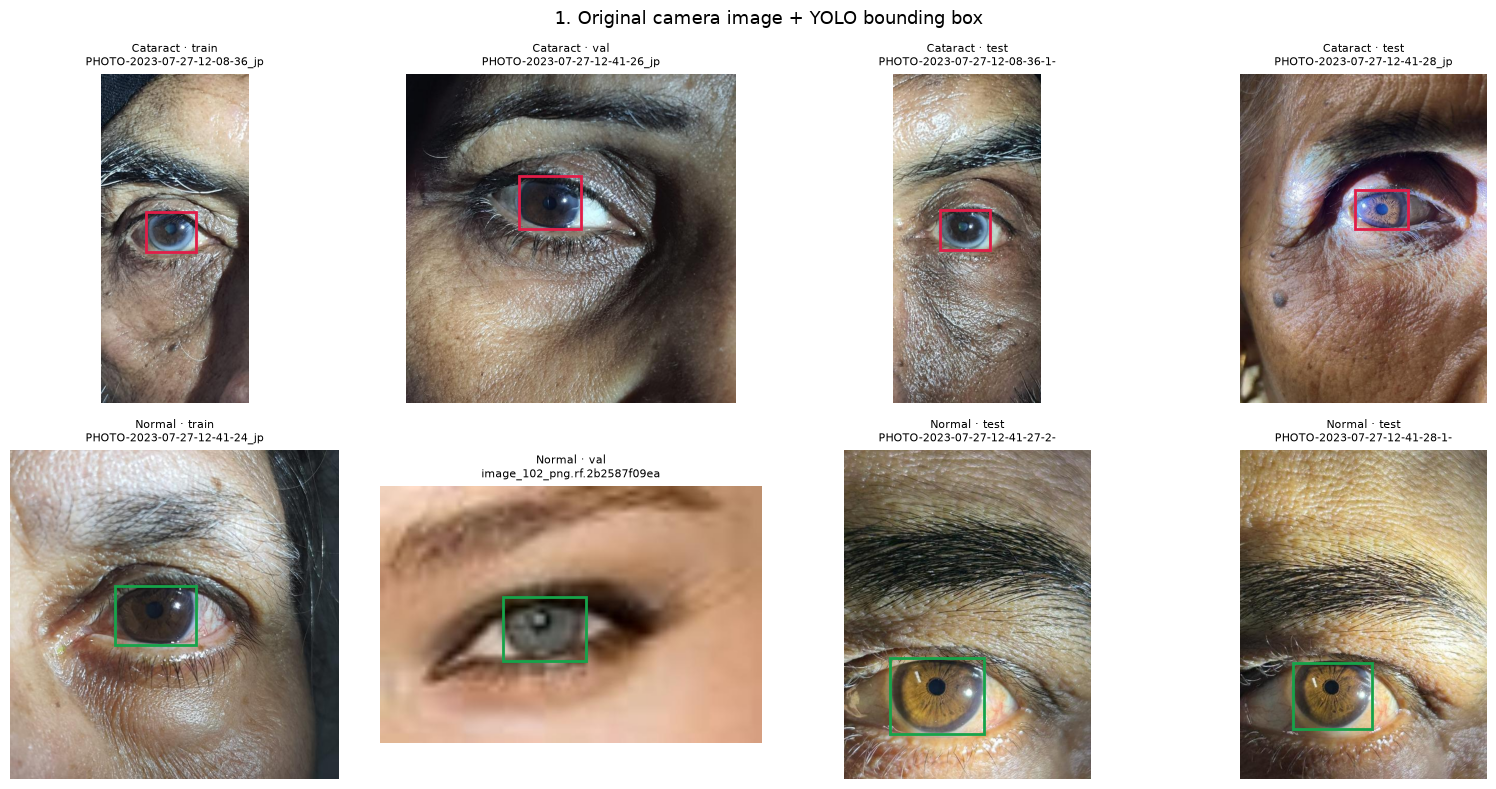

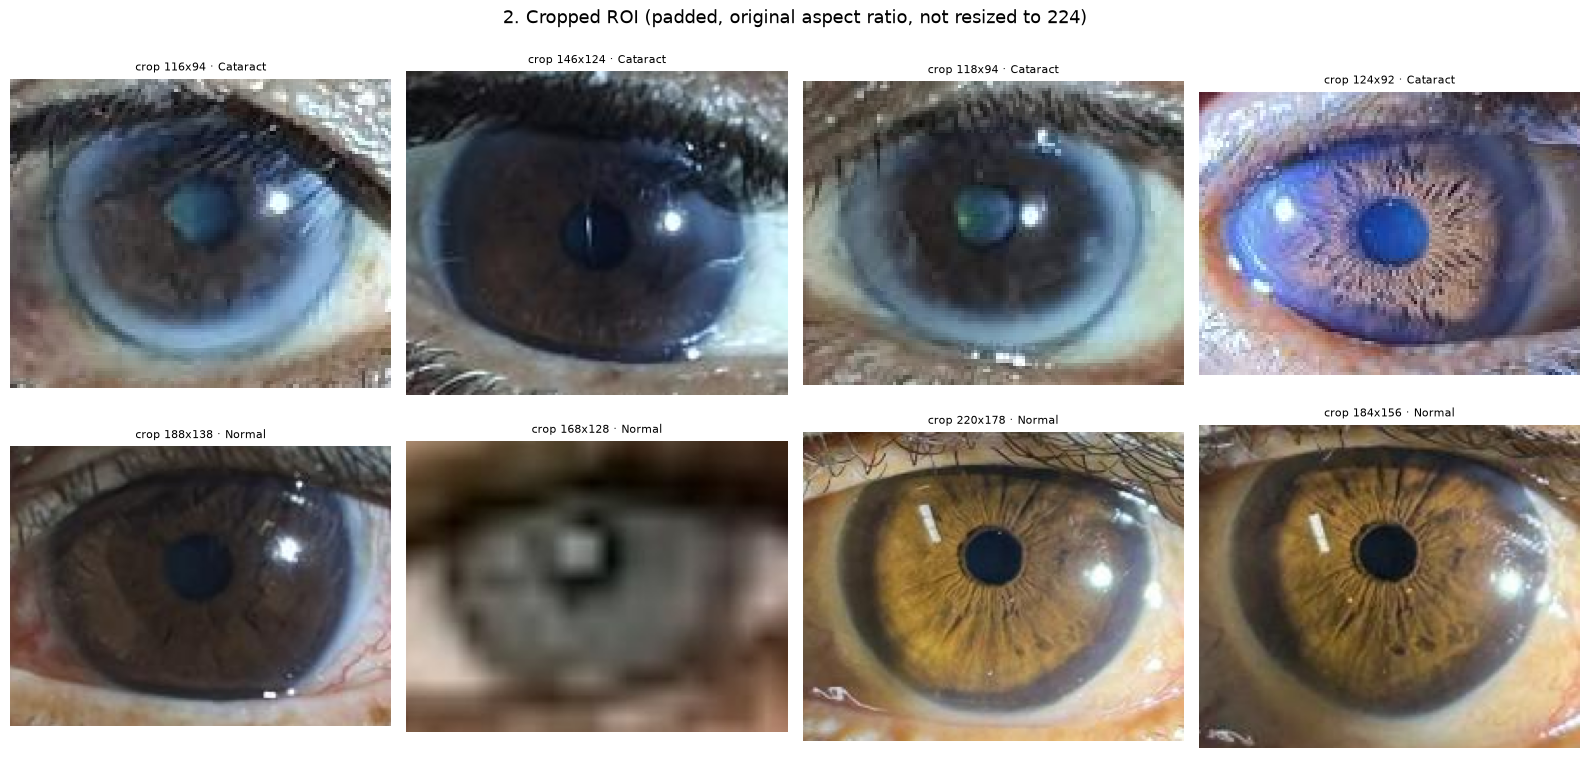

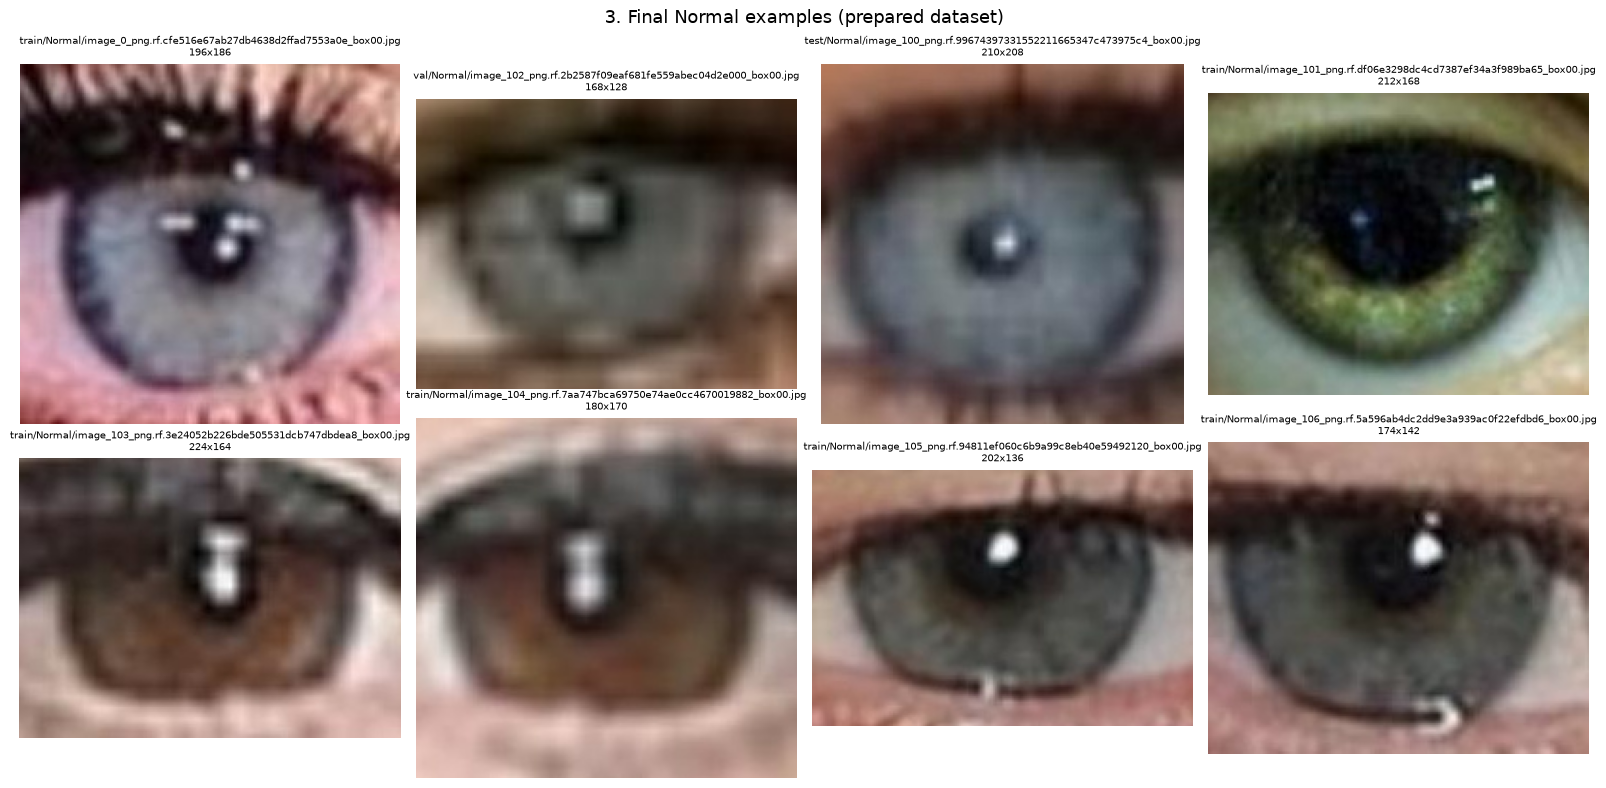

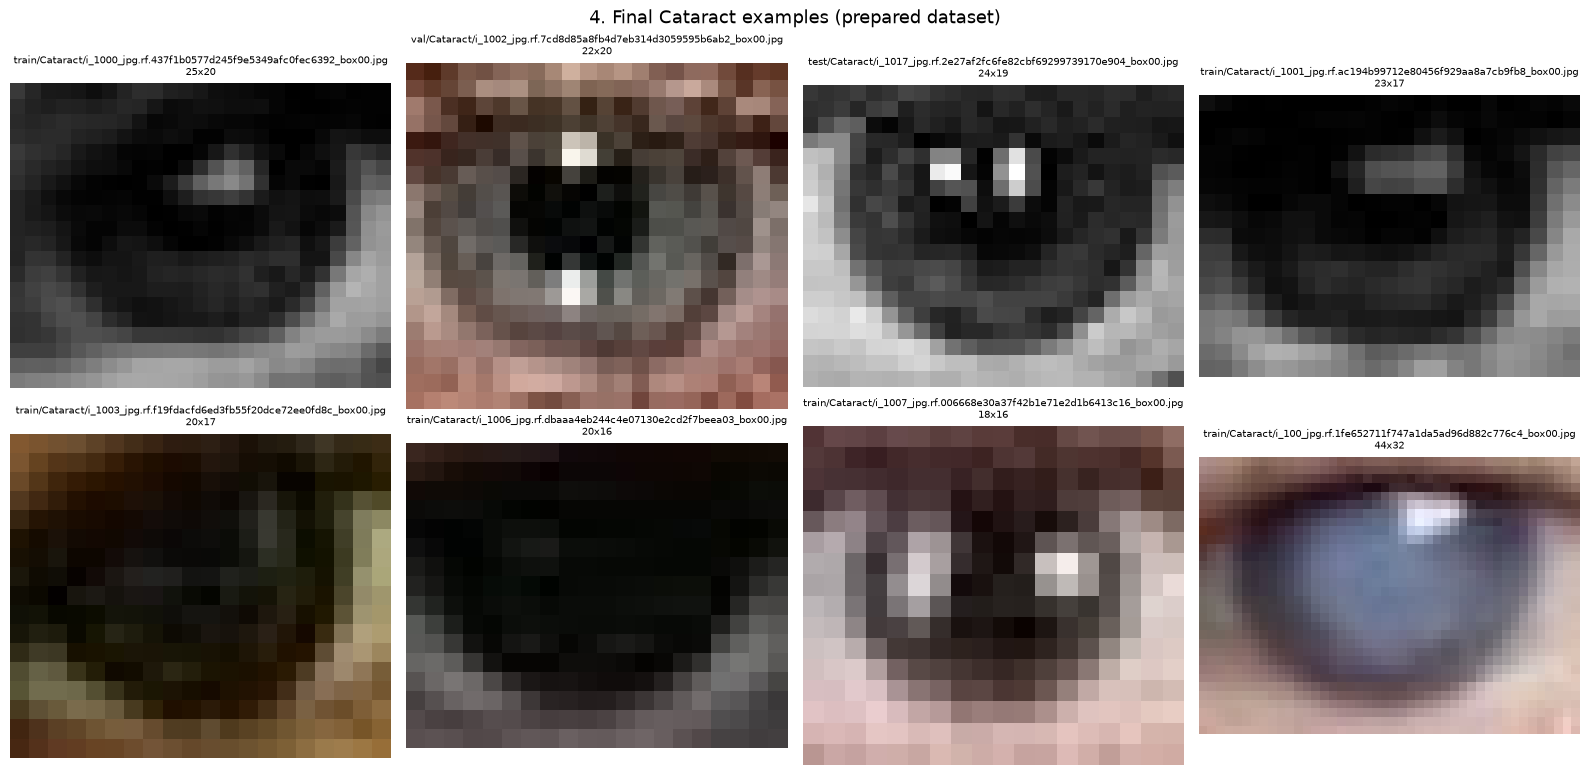

Saved previews to d:\Practice Projects\Disease Detection\reports\camera_dataset_preparation\previews
Preview files: ['01_original_with_yolo_bbox.png', '02_crop_Cataract_0.jpg', '02_crop_Cataract_1.jpg', '02_crop_Cataract_2.jpg', '02_crop_Cataract_3.jpg', '02_crop_Normal_0.jpg', '02_crop_Normal_1.jpg', '02_crop_Normal_2.jpg', '02_crop_Normal_3.jpg', '02_cropped_roi.png', '03_final_normal_examples.png', '04_final_cataract_examples.png', 'final_Cataract_00.jpg', 'final_Cataract_01.jpg', 'final_Cataract_02.jpg', 'final_Cataract_03.jpg', 'final_Cataract_04.jpg', 'final_Cataract_05.jpg', 'final_Cataract_06.jpg', 'final_Cataract_07.jpg', 'final_Normal_00.jpg', 'final_Normal_01.jpg', 'final_Normal_02.jpg', 'final_Normal_03.jpg', 'final_Normal_04.jpg', 'final_Normal_05.jpg', 'final_Normal_06.jpg', 'final_Normal_07.jpg']


In [9]:
# STEP 7 — Representative previews
for old in PREVIEW_DIR.glob("*"):
    if old.is_file():
        old.unlink()

CLASS_COLORS = {0: "#e11d48", 1: "#16a34a"}


def pick_source_examples(class_id: int, n: int = 4) -> list[dict]:
    pool = [
        r
        for r in records
        if r.get("readable")
        and r.get("boxes")
        and class_id in (r.get("class_ids") or [])
        and r.get("width", 0) and r["width"] >= 80
    ]
    pool = sorted(pool, key=lambda r: (r["split"], r["filename"]))
    # mix splits if possible
    chosen = []
    by_split = defaultdict(list)
    for rec in pool:
        by_split[rec["split"]].append(rec)
    for split in SPLITS:
        if len(chosen) >= n:
            break
        if by_split[split]:
            chosen.append(by_split[split][0])
    for rec in pool:
        if len(chosen) >= n:
            break
        if rec not in chosen:
            chosen.append(rec)
    if len(chosen) < n:
        fallback = [r for r in records if r.get("readable") and class_id in (r.get("class_ids") or [])]
        for rec in fallback:
            if rec not in chosen:
                chosen.append(rec)
            if len(chosen) >= n:
                break
    return chosen[:n]


# 1. Original + YOLO box
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
preview_sources = []
for row_i, cid in enumerate((0, 1)):
    examples = pick_source_examples(cid, 4)
    preview_sources.append(examples)
    for col_i in range(4):
        ax = axes[row_i][col_i]
        ax.axis("off")
        if col_i >= len(examples):
            continue
        rec = examples[col_i]
        img = Image.open(rec["image_path"]).convert("RGB")
        w, h = img.size
        ax.imshow(img)
        for box in rec["boxes"]:
            x1, y1, x2, y2 = yolo_to_xyxy(box["xc"], box["yc"], box["bw"], box["bh"], w, h)
            ax.add_patch(
                Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2.0,
                    edgecolor=CLASS_COLORS.get(box["class_id"], "yellow"),
                )
            )
        ax.set_title(f"{CAMERA_CLASS_MAP[cid]} · {rec['split']}\n{rec['filename'][:28]}", fontsize=8)

fig.suptitle("1. Original camera image + YOLO bounding box", fontsize=13)
fig.tight_layout()
fig.savefig(PREVIEW_DIR / "01_original_with_yolo_bbox.png", dpi=140)
plt.show()

# 2. Cropped ROI for the same examples (first matching box of that class)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row_i, cid in enumerate((0, 1)):
    examples = preview_sources[row_i]
    for col_i in range(4):
        ax = axes[row_i][col_i]
        ax.axis("off")
        if col_i >= len(examples):
            continue
        rec = examples[col_i]
        img = Image.open(rec["image_path"]).convert("RGB")
        w, h = img.size
        box = next(b for b in rec["boxes"] if b["class_id"] == cid)
        ix1, iy1, ix2, iy2, _, _ = padded_clamp_box(
            box["xc"], box["yc"], box["bw"], box["bh"], w, h, PAD_RATIO, PAD_MIN_PX
        )
        crop = img.crop((ix1, iy1, ix2, iy2)).convert("RGB")
        ax.imshow(crop)
        ax.set_title(f"crop {crop.size[0]}x{crop.size[1]} · {CAMERA_CLASS_MAP[cid]}", fontsize=8)
        crop.save(PREVIEW_DIR / f"02_crop_{CAMERA_CLASS_MAP[cid]}_{col_i}.jpg", quality=92)

fig.suptitle("2. Cropped ROI (padded, original aspect ratio, not resized to 224)", fontsize=13)
fig.tight_layout()
fig.savefig(PREVIEW_DIR / "02_cropped_roi.png", dpi=140)
plt.show()


def list_final_crops(split: str, name: str) -> list[Path]:
    folder = PREPARED_DIR / split / name
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS])


def pick_final_grid(name: str, n: int = 8) -> list[Path]:
    chosen = []
    for split in SPLITS:
        files = list_final_crops(split, name)
        if files:
            chosen.append(files[0])
        if len(chosen) >= n:
            break
    for split in SPLITS:
        for p in list_final_crops(split, name)[1:]:
            if len(chosen) >= n:
                break
            if p not in chosen:
                chosen.append(p)
        if len(chosen) >= n:
            break
    return chosen[:n]


# 3–4. Final class examples
for name, fname, title in (
    ("Normal", "03_final_normal_examples.png", "3. Final Normal examples (prepared dataset)"),
    ("Cataract", "04_final_cataract_examples.png", "4. Final Cataract examples (prepared dataset)"),
):
    paths = pick_final_grid(name, 8)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= len(paths):
            continue
        img = Image.open(paths[i]).convert("RGB")
        ax.imshow(img)
        rel = paths[i].relative_to(PREPARED_DIR)
        ax.set_title(f"{rel.as_posix()}\n{img.size[0]}x{img.size[1]}", fontsize=7)
        img.save(PREVIEW_DIR / f"final_{name}_{i:02d}.jpg", quality=92)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    fig.savefig(PREVIEW_DIR / fname, dpi=140)
    plt.show()

print("Saved previews to", PREVIEW_DIR)
print("Preview files:", sorted(p.name for p in PREVIEW_DIR.iterdir() if p.is_file()))


## STEP 8 — Duplicate / leakage checks

Exact file hashes among generated (accepted) crops, and across `train` / `val` / `test`.

If the same hash appears in more than one split, it is **reported** and **not moved**. Source split boundaries stay as-is.


In [10]:
# STEP 8 — Exact duplicate hashes among accepted crops; cross-split leakage
def md5_file(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()


accepted_files = []
for split in SPLITS:
    for name in CAMERA_CLASS_MAP.values():
        folder = PREPARED_DIR / split / name
        for p in sorted(folder.glob("*")):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                accepted_files.append({"split": split, "disease_name": name, "path": p, "crop_filename": p.name})

for item in accepted_files:
    item["md5"] = md5_file(item["path"])

hash_to_items = defaultdict(list)
for item in accepted_files:
    hash_to_items[item["md5"]].append(item)

within_duplicates = []
cross_split_duplicates = []
for digest, items in hash_to_items.items():
    if len(items) < 2:
        continue
    splits_present = {it["split"] for it in items}
    rec = {
        "md5": digest,
        "n": len(items),
        "splits": sorted(splits_present),
        "files": [f"{it['split']}/{it['disease_name']}/{it['crop_filename']}" for it in items],
    }
    if len(splits_present) > 1:
        cross_split_duplicates.append(rec)
    else:
        within_duplicates.append(rec)

print("Accepted crop files hashed:", len(accepted_files))
print("Unique hashes:", len(hash_to_items))
print("Exact duplicate groups (same split):", len(within_duplicates))
print("Exact duplicate groups (CROSS-SPLIT):", len(cross_split_duplicates))

if within_duplicates:
    print("\nSame-split duplicate groups (reported, not deleted):")
    for rec in within_duplicates[:20]:
        print(" ", rec["md5"][:12], rec["files"])

if cross_split_duplicates:
    print("\nCROSS-SPLIT duplicate groups (reported, NOT moved):")
    for rec in cross_split_duplicates:
        print(" ", rec["md5"][:12], rec["files"])
else:
    print("No cross-split duplicate hashes among accepted crops.")

# Overlap vs existing 5885 fundus images (content MD5)
print("\nHashing existing 5885-image fundus dataset for overlap (read-only)...")
meta_existing = pd.read_csv(EXISTING_META)
print("Existing metadata rows:", len(meta_existing), "expected", EXPECTED_FUNDUS_ROWS)
existing_md5 = {}
missing_existing = 0
for p in (Path(x) for x in meta_existing["image_path"].astype(str)):
    if not p.exists():
        missing_existing += 1
        continue
    existing_md5[hashlib.md5(p.read_bytes()).hexdigest()] = p.name
print("Hashed existing fundus files:", len(existing_md5), "missing:", missing_existing)

source_md5_hits = []
for rec in records:
    digest = hashlib.md5(Path(rec["image_path"]).read_bytes()).hexdigest()
    rec["md5"] = digest
    if digest in existing_md5:
        source_md5_hits.append((rec["filename"], existing_md5[digest]))

prepared_md5_hits = []
for item in accepted_files:
    if item["md5"] in existing_md5:
        prepared_md5_hits.append((item["crop_filename"], existing_md5[item["md5"]]))

print("Source camera vs fundus MD5 matches:", len(source_md5_hits))
print("Prepared crops vs fundus MD5 matches:", len(prepared_md5_hits))
overlap_result = {
    "existing_metadata_rows": int(len(meta_existing)),
    "source_camera_md5_matches": len(source_md5_hits),
    "prepared_crop_md5_matches": len(prepared_md5_hits),
    "content_overlap_with_5885": bool(source_md5_hits or prepared_md5_hits),
    "source_match_examples": source_md5_hits[:20],
    "prepared_match_examples": prepared_md5_hits[:20],
}


Accepted crop files hashed: 1870
Unique hashes: 1870
Exact duplicate groups (same split): 0
Exact duplicate groups (CROSS-SPLIT): 0
No cross-split duplicate hashes among accepted crops.

Hashing existing 5885-image fundus dataset for overlap (read-only)...
Existing metadata rows: 5885 expected 5885
Hashed existing fundus files: 5885 missing: 0
Source camera vs fundus MD5 matches: 0
Prepared crops vs fundus MD5 matches: 0


## STEP 9 — Final validation

Assertions cover prepared directories, class set, metadata completeness, crop readability, class IDs, cross-split hashes, source split boundaries, and that the existing 5885-image fundus pipeline was not modified.


In [11]:
# STEP 9 — Assertions and final status report
PROTECTED_AFTER = {rel: file_fingerprint(PROJECT_ROOT / rel) for rel in PROTECTED_RELATIVE}
protected_unchanged = True
protected_mismatches = []
for rel in PROTECTED_RELATIVE:
    before = PROTECTED_BEFORE[rel]
    after = PROTECTED_AFTER[rel]
    if before != after:
        protected_unchanged = False
        protected_mismatches.append(rel)

# Re-open every accepted crop
corrupt_generated = []
prepared_index = []
unexpected_classes = set()
for split in SPLITS:
    split_dir = PREPARED_DIR / split
    if not split_dir.exists():
        continue
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        unexpected_classes.add(class_dir.name)
        for p in sorted(class_dir.iterdir()):
            if not p.is_file() or p.suffix.lower() not in IMAGE_EXTS:
                continue
            prepared_index.append({"split": split, "disease_name": class_dir.name, "crop_filename": p.name, "path": p})
            try:
                with Image.open(p) as im:
                    im.verify()
                with Image.open(p) as im:
                    rgb = im.convert("RGB")
                    if min(rgb.size) <= 0:
                        raise ValueError("non-positive size")
            except Exception as exc:
                corrupt_generated.append({"path": str(p), "error": str(exc)})

accepted_names = set(accepted_df["crop_filename"].astype(str)) if len(accepted_df) else set()
prepared_names = {r["crop_filename"] for r in prepared_index}
missing_meta = sorted(prepared_names - accepted_names)
extra_meta_without_file = sorted(accepted_names - prepared_names)

# Split boundary: every accepted crop's folder split == source_split
split_mismatch = []
if len(accepted_df):
    for _, row in accepted_df.iterrows():
        expected_path = PREPARED_DIR / str(row["source_split"]) / str(row["disease_name"]) / str(row["crop_filename"])
        if not expected_path.exists():
            split_mismatch.append(str(expected_path))
        if str(row["source_split"]) not in SPLITS:
            split_mismatch.append(f"unexpected split {row['source_split']}")

on_disk_split_mismatch = [r for r in prepared_index if r["split"] not in SPLITS]

invalid_ids = []
if len(accepted_df):
    for _, row in accepted_df.iterrows():
        try:
            cid = int(row["class_id"])
        except (TypeError, ValueError):
            invalid_ids.append(row["crop_filename"])
            continue
        if cid not in VALID_CLASS_IDS:
            invalid_ids.append(row["crop_filename"])
        if CAMERA_CLASS_MAP.get(cid) != row["disease_name"]:
            invalid_ids.append(row["crop_filename"])

source_count_ok = (
    split_image_counts == EXPECTED_SPLIT_COUNTS
    and len(records) == EXPECTED_TOTAL_IMAGES
    and split_label_counts == EXPECTED_SPLIT_COUNTS
)

checks = {
    "train_val_test_directories_exist": all((PREPARED_DIR / s).is_dir() for s in SPLITS)
    and all((PREPARED_DIR / s / n).is_dir() for s in SPLITS for n in CAMERA_CLASS_MAP.values()),
    "only_normal_and_cataract_present": unexpected_classes <= set(CAMERA_CLASS_MAP.values()),
    "every_generated_crop_has_metadata": not missing_meta,
    "no_corrupted_generated_crops": not corrupt_generated,
    "no_invalid_class_ids": not invalid_ids,
    "no_cross_split_duplicate_image_hashes": not cross_split_duplicates,
    "source_split_boundaries_preserved": not split_mismatch and not on_disk_split_mismatch,
    "existing_5885_image_dataset_untouched": protected_unchanged
    and len(meta_existing) == EXPECTED_FUNDUS_ROWS,
    "source_audit_counts_match_previous": source_count_ok,
    "accepted_files_match_metadata": not extra_meta_without_file,
}

all_pass = all(checks.values())
status = "PASS" if all_pass else "FAIL"

summary = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "status": status,
    "source_image_counts": split_image_counts,
    "source_label_counts": split_label_counts,
    "source_total_images": len(records),
    "valid_label_files": n_valid_label_files,
    "invalid_or_incomplete_label_files": n_invalid_label_files,
    "invalid_yolo_box_rows": len(invalid_box_rows),
    "empty_labels": len(empty_labels),
    "missing_labels": len(unmatched_images),
    "unmatched_label_files": len(unmatched_labels),
    "images_with_multiple_boxes": len(multi_box_records),
    "source_box_class_counts": {str(k): int(v) for k, v in sorted(class_id_counter.items())},
    "generated_crop_attempts": n_generated_attempts,
    "accepted_crop_counts_total": int(len(accepted_df)),
    "rejected_crop_counts": int(len(rejected_df)),
    "final_class_distribution": {
        "Normal": int((accepted_df["disease_name"] == "Normal").sum()) if len(accepted_df) else 0,
        "Cataract": int((accepted_df["disease_name"] == "Cataract").sum()) if len(accepted_df) else 0,
    },
    "train_val_test_distribution": final_dist,
    "class_mapping": {str(k): v for k, v in CAMERA_CLASS_MAP.items()},
    "overlap_result": overlap_result,
    "processing_configuration": PROCESSING_CONFIG,
    "duplicate_checks": {
        "accepted_files_hashed": len(accepted_files),
        "unique_hashes": len(hash_to_items),
        "same_split_duplicate_groups": len(within_duplicates),
        "cross_split_duplicate_groups": len(cross_split_duplicates),
        "cross_split_examples": cross_split_duplicates[:20],
        "same_split_examples": within_duplicates[:20],
    },
    "validation_checks": checks,
    "protected_file_mismatches": protected_mismatches,
    "corrupt_generated": corrupt_generated[:20],
    "missing_metadata_for_files": missing_meta[:20],
    "prepared_dir": str(PREPARED_DIR),
    "existing_5885_image_dataset_modified": "NO",
    "existing_efficientnetv2_b0_modified": "NO",
    "existing_84_94_accuracy_modified": "NO",
    "next_step": (
        "NEXT STEP = train/evaluate a separate camera-image classifier using only the prepared "
        "camera dataset, while keeping the existing fundus model completely separate."
    ),
}

summary_path = REPORT_DIR / "camera_dataset_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Wrote", summary_path)

print("\nAssertion results:")
for key, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {key}")
if protected_mismatches:
    print("Protected file mismatches:", protected_mismatches)
if missing_meta:
    print("Prepared files missing metadata:", missing_meta[:10])
if extra_meta_without_file:
    print("Metadata accepted rows missing files:", extra_meta_without_file[:10])
if corrupt_generated:
    print("Corrupt generated crops:", corrupt_generated[:10])

print("\n" + "=" * 72)
print(f"CAMERA DATASET PREPARATION STATUS: {status}")
print("Source:")
print(f"{len(records)} images")
print("Final prepared dataset:")
print("Train:")
print(f"  Normal = {final_dist['train']['Normal']}")
print(f"  Cataract = {final_dist['train']['Cataract']}")
print("Validation:")
print(f"  Normal = {final_dist['val']['Normal']}")
print(f"  Cataract = {final_dist['val']['Cataract']}")
print("Test:")
print(f"  Normal = {final_dist['test']['Normal']}")
print(f"  Cataract = {final_dist['test']['Cataract']}")
print("Rejected:")
print(len(rejected_df))
print("Cross-split duplicates:")
print(len(cross_split_duplicates))
print("Class mapping:")
print("0 = Cataract")
print("1 = Normal")
print("Existing 5885-image dataset modified: NO")
print("Existing EfficientNetV2-B0 modified: NO")
print("Existing 84.94% accuracy modified: NO")
print("=" * 72)
print(
    "NEXT STEP = train/evaluate a separate camera-image classifier using only the prepared "
    "camera dataset, while keeping the existing fundus model completely separate."
)
print("This notebook did not start model training.")


Wrote d:\Practice Projects\Disease Detection\reports\camera_dataset_preparation\camera_dataset_summary.json

Assertion results:
  [PASS] train_val_test_directories_exist
  [PASS] only_normal_and_cataract_present
  [PASS] every_generated_crop_has_metadata
  [PASS] no_corrupted_generated_crops
  [PASS] no_invalid_class_ids
  [PASS] no_cross_split_duplicate_image_hashes
  [PASS] source_split_boundaries_preserved
  [PASS] existing_5885_image_dataset_untouched
  [PASS] source_audit_counts_match_previous
  [PASS] accepted_files_match_metadata

CAMERA DATASET PREPARATION STATUS: PASS
Source:
1979 images
Final prepared dataset:
Train:
  Normal = 191
  Cataract = 1110
Validation:
  Normal = 38
  Cataract = 341
Test:
  Normal = 29
  Cataract = 161
Rejected:
114
Cross-split duplicates:
0
Class mapping:
0 = Cataract
1 = Normal
Existing 5885-image dataset modified: NO
Existing EfficientNetV2-B0 modified: NO
Existing 84.94% accuracy modified: NO
NEXT STEP = train/evaluate a separate camera-image cla